<a href="https://colab.research.google.com/github/danielsiqueiradev/projetoMVP_PUC/blob/main/Projeto_MVP_PUC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP — Machine Learning & Analytics
**Nome:** Daniel da Silva Ferreira de Siqueira

**Matrícula:** 4052026000101

**Data:** 28/06/2026

**Dataset:** Base Histórica Kinoplex (Binarizada e Enriquecida via APIs)

**Link:** https://raw.githubusercontent.com/danielsiqueiradev/projetoMVP_PUC/refs/heads/main/Base_Kinoplex_ML_Binarizada.csv

**Tipo de problema:** Regressão (Forecast de Demanda / Bilheteria)

## 1. Definição do Problema
O desafio deste projeto é prever a quantidade de ingressos que serão vendidos para os filmes em exibição na rede Kinoplex. Ter uma estimativa preditiva precisa do público permite uma alocação mais inteligente do *staff* de atendimento e um melhor gerenciamento de suprimentos da bomboniere, evitando filas para o cliente e gargalos operacionais.

O problema é modelado como uma tarefa de **Regressão**, utilizando métricas como o Erro Médio Absoluto (MAE) para tangibilizar o desempenho do algoritmo diretamente em "número físico de ingressos".

## 2. Ambiente, bibliotecas e reprodutibilidade

Para garantir a reprodutibilidade integral do projeto e evitar divergências de execução na avaliação do MVP, consolidamos todas as configurações de ambiente, dependências e sementes aleatórias nesta seção.

### 2.1 Bibliotecas Utilizadas
A arquitetura da solução baseia-se nas seguintes bibliotecas principais:
* **Manipulação e Análise de Dados:** `pandas`, `numpy`, `re` (expressões regulares) e `datetime`.
* **Machine Learning e Métricas:** `scikit-learn` (para divisão de dados, métricas de avaliação como MAE e RMSE, e inicialização dos algoritmos de regressão como `RandomForestRegressor` e `HistGradientBoostingRegressor`).
* **Integração e Coleta Externa (APIs):** `requests` (conexão com TMDB e OMDB) e `google-api-python-client` (conexão com a API nativa do YouTube).
* **Processamento de Linguagem Natural (NLP):** `transformers` (pipeline da Hugging Face para análise de sentimento).
* **Segurança de Credenciais:** `google.colab.userdata` (garantindo que as chaves de API não fiquem expostas no código-fonte).

### 2.2 Reprodutibilidade (Seed)
Para que os resultados e a convergência dos algoritmos estocásticos (como árvores de decisão e *ensembles*) sejam estritamente idênticos em qualquer execução e máquina, fixamos a semente aleatória global do projeto.
* **Seed padrão:** Utilizamos o valor `7` (`np.random.seed(7)` e parâmetros `random_state=7`) na inicialização do ambiente, particionamento e dos regressores. Essa trava garante a rastreabilidade exata da divisão de dados e da modelagem durante a avaliação da banca.

### 2.3 Observações de Ambiente (CPU/GPU) e Dependências
* **Ambiente Base:** O desenvolvimento e os testes foram homologados na infraestrutura em nuvem do **Google Colab**.
* **Aceleração de Hardware (GPU):** Todo o pré-processamento de dados tabulares e o treinamento dos modelos de Machine Learning (via `scikit-learn`) rodam de maneira performática e fluida em instâncias padrão de **CPU**. Contudo, recomenda-se fortemente a ativação de um acelerador **GPU (ex: T4 no Colab)** para a etapa de coleta e predição, visto que a inferência do pipeline de NLP (Hugging Face) na análise de comentários do YouTube sofre um gargalo significativo de tempo de execução se operada apenas via CPU.
* **Versões:** O script utiliza o ecossistema atualizado do Colab. É mandatório que o `scikit-learn` esteja em versão igual ou superior a `1.0` para que o suporte ao estimador `HistGradientBoostingRegressor` (com suporte a valores nulos) seja nativo e não demande importações experimentais.

In [35]:
# Importando as bibliotecas
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

print("Bibliotecas importadas!")

Bibliotecas importadas!


In [19]:
# Puxando a base direto do repositório
url_github = "https://raw.githubusercontent.com/danielsiqueiradev/projetoMVP_PUC/refs/heads/main/Base_Kinoplex_ML_Binarizada.csv"
df = pd.read_csv(url_github)

print(f"Base carregada com sucesso! O dataset tem {df.shape[0]} linhas e {df.shape[1]} colunas.")
display(df.head())

Base carregada com sucesso! O dataset tem 45544 linhas e 69 colunas.


,MES_EXIBICAO,ANO_EXIBICAO,TITULO_ORIGINAL,PUBLICO,ANO_LANCAMENTO,rotten_tomatoes,yt_views,yt_likes,yt_sentiment,ORCAMENTO_USD,...,GENERO_Faroeste,GENERO_Ficção científica,GENERO_Guerra,GENERO_História,GENERO_Mistério,GENERO_Música,GENERO_Nao Encontrado,GENERO_Romance,GENERO_Terror,GENERO_Thriller
0,1,2014,47 RONIN,195,2013.0,16.0,19838656.0,60937.0,3.4,175000000.0,...,0,0,0,0,0,0,0,0,0,0
1,1,2014,ATÉ QUE A SORTE NOS SEPARE 2,4239,2013.0,0.0,59706.0,341.0,2.2,0.0,...,0,0,0,0,0,0,0,0,0,0
2,1,2014,CONFISSÕES DE ADOLESCENTE - O FILME,1101,2014.0,0.0,732455.0,4046.0,3.4,0.0,...,0,0,0,0,0,0,0,0,0,0
3,1,2014,DEVIL'S DUE,738,2014.0,21.0,7073646.0,31338.0,1.8,7000000.0,...,0,0,0,0,0,0,0,0,1,0
4,1,2014,ENDER'S GAME,420,2013.0,63.0,5716340.0,21622.0,3.3,110000000.0,...,0,1,0,0,0,0,0,0,0,0


## 3. Seleção e carga dos dados

### 3.1 Fonte dos dados

**Nome do dataset:** Base Histórica de Bilheteria Kinoplex Enriquecida (derivada dos Relatórios de Bilheteria da ANCINE).

**Link da fonte:**
* **Dados Brutos (Governo Federal):** [Portal de Dados Abertos - ANCINE](https://dados.gov.br/dados/conjuntos-dados/relatorio-de-bilheteria-diaria-de-obras-informadas-pelas-distribuidoras)
* **Dataset Final Processado:** [Repositório GitHub do Projeto (Raw CSV)](https://raw.githubusercontent.com/danielsiqueiradev/projetoMVP_PUC/refs/heads/main/Base_Kinoplex_ML_Binarizada.csv)

**Por que este dataset foi escolhido:**
A escolha decorre da necessidade de solucionar uma dor latente e real no setor de exibição cinematográfica: a previsibilidade de demanda para alocação de salas. Em vez de utilizar datasets acadêmicos pré-fabricados, optou-se por construir uma base estruturada do zero que espelha exatamente o ecossistema operacional da rede Kinoplex (Cinemas São Luiz S.A.). Isso garante que a modelagem preditiva e o MVP final possuam aplicação prática imediata e alto valor de negócio.

**Restrições e condições consideradas:**
O dataset original da ANCINE possui uma volumetria massiva, registrando operações diárias de todos os cinemas do Brasil desde o ano de 2014. Para viabilizar a hospedagem pública no GitHub e garantir uma execução fluida na memória do Google Colab, aplicamos restrições técnicas no escopo da amostra:
1. Filtro de exclusividade para as unidades da rede Kinoplex.
2. Remoção de filmes da "cauda longa" (performance agregada historicamente inferior a 5.000 ingressos). Isso restringe o campo de visão atual do modelo aos lançamentos comerciais de médio e grande porte.

**Questões de ética, privacidade e confidencialidade:**
O pipeline de dados opera em total conformidade com as diretrizes éticas vigentes e com a Lei Geral de Proteção de Dados (LGPD). A matéria-prima inicial provém de uma fonte governamental de domínio público e acesso aberto. O dataset resultante lida exclusivamente com métricas agregadas macroeconômicas (contagem total de ingressos por complexo) e metadados artísticos (orçamento do TMDB, engajamento do YouTube). Em nenhuma etapa há processamento, coleta ou armazenamento de informações pessoais ou sensíveis de clientes, garantindo privacidade total.

### 3.2 Dicionário de dados

Abaixo estão listados os principais atributos (features) do dataset após o enriquecimento e engenharia de variáveis. Para manter a concisão deste documento, as dezenas de colunas geradas pelo *One-Hot Encoding* (Gêneros, Classificações e Unidades) foram agrupadas logicamente.

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| **TITULO_ORIGINAL** | Texto | Título original da obra cinematográfica. | Não | Utilizada apenas para identificação da linha e conferência, removida antes do treino. |
| **ORCAMENTO_USD** | Numérica | Orçamento do filme em dólares americanos (TMDB). | Sim | Balizador financeiro do escopo da produção. |
| **yt_views** | Numérica | Total de visualizações do trailer oficial no YouTube. | Sim | Principal métrica de engajamento e hype pré-lançamento. |
| **yt_likes** | Numérica | Total de curtidas do trailer no YouTube. | Sim | Medida complementar de aprovação prévia. |
| **yt_sentiment** | Numérica | Nota média (1 a 5) extraída dos comentários do trailer via NLP (Hugging Face). | Sim | Traduz a recepção do público brasileiro (sentimento positivo ou negativo). |
| **rotten_tomatoes** | Numérica | Nota da crítica especializada (0 a 100) via OMDB. | Sim | Sinaliza a qualidade técnica avaliada pela mídia. |
| **MES_DE_FERIAS** | Categórica (Binária) | Flag (0 ou 1) para os meses de janeiro, julho e dezembro. | Sim | Captura a alta sazonalidade do calendário escolar. |
| **E_FRANQUIA** | Categórica (Binária) | Flag (0 ou 1) indicando se o filme é uma sequência/spin-off. | Sim | Informa à máquina a existência de uma *fanbase* cativa. |
| **SELO_BLOCKBUSTER** | Categórica (Binária) | Flag (0 ou 1) para filmes com altíssimo orçamento ou views. | Sim | Impede subestimativas em lançamentos gigantes. |
| **SELO_NICHO** | Categórica (Binária) | Flag (0 ou 1) para filmes de orçamento baixo e pouco hype. | Sim | Corrige o "viés de grandes números", forçando previsões realistas para filmes menores. |
| **GENERO_\*** *(ex: GENERO_Acao)* | Categórica (One-Hot) | Colunas binárias para cada gênero do filme. | Sim | Informa o perfil narrativo da obra. |
| **CLASS_\*** *(ex: CLASS_14)* | Categórica (One-Hot) | Colunas binárias indicando a restrição de idade. | Sim | Filtra o público-alvo potencial (ex: filmes infantis vs. terror adulto). |
| **CINEMA_\*** *(ex: CINEMA_KINOPLEX TIJUCA)* | Categórica (One-Hot) | Colunas binárias identificando a unidade de exibição. | Sim | Permite que o modelo ajuste a previsão ao "DNA" e tamanho de cada praça específica. |
| **PUBLICO** | **Alvo (Target)** | **Quantidade total de ingressos vendidos (mensal) por complexo.** | **Alvo** | **Variável contínua que o modelo de regressão deve prever.** |

## 4. Análise Exploratória e Pré-processamento

### 4.1 Síntese da análise exploratória

A etapa de Análise Exploratória de Dados (EDA) revelou características estruturais cruciais do comportamento do consumidor de cinema, guiando diretamente as decisões de pré-processamento e a escolha dos algoritmos:

* **Distribuição do Target (Assimetria e Outliers):** A variável alvo (`PUBLICO`) não possui uma distribuição normal. Ela apresenta uma severa assimetria à direita (*right-skewed*), onde a esmagadora maioria das exibições concentra-se em volumes médios/baixos, enquanto uma minoria de *blockbusters* e fenômenos virais atinge a casa dos milhões. Não há "balanceamento", há uma cauda longa natural do varejo de entretenimento.
* **Escalas Discrepantes:** Constatou-se uma variação massiva de escala entre as *features*. Variáveis como Orçamento (em milhões de dólares) e Visualizações no YouTube contrastam fortemente com notas de sentimento (1 a 5), notas da crítica (0 a 100) e centenas de colunas binarizadas (0 ou 1) geradas pelo *One-Hot Encoding* de gêneros e cinemas.
* **Valores Ausentes e Categorias Raras:** Observou-se a ausência de orçamento reportado e de trailers oficiais para obras menores ou independentes. A estratégia adotada foi o preenchimento com zero (`fillna(0)`), ensinando ao modelo que a ausência dessas cifras milionárias é, por si só, um indicativo de escopo reduzido. Categorias muito raras de gêneros geraram matrizes esparsas (*sparse matrices*) após a binarização.
* **Direcionamento de Modelagem:** A não-linearidade das relações (ex: filmes com baixo orçamento e baixo trailer oficial, mas com altíssima bilheteria impulsionada por viralização, como *Backrooms*) e a presença de valores extremos indicam que modelos lineares tradicionais tendem a falhar. Os dados sugerem que algoritmos de particionamento e *ensembles* baseados em árvores (*Random Forest* e *Gradient Boosting*) são a escolha ideal, pois lidam nativamente com escalas variadas e são robustos contra *outliers*.
* **Mudança de Estratégia:** A principal quebra de paradigma gerada pela EDA foi a identificação de um forte "ruído geográfico". O mesmo filme performa de maneiras diametralmente opostas dependendo da unidade do cinema. Isso justificou a inclusão das unidades binarizadas no modelo global atual e fundamentou a recomendação de negócio para a futura criação de **Modelos Locais** (um pipeline de treinamento individual para cada praça).

### 4.2 Limpeza e Engenharia de Features

Consolidando os achados da exploração, os dados brutos passaram pelo seguinte pipeline de formatação (ETL) para gerar o *dataset* limpo consumido neste notebook:
* **Tratamento de Inconsistências:** Limpeza de valores nulos residuais e padronização das strings de títulos para garantir o *match* correto entre as fontes da ANCINE e as APIs externas.
* **Binarização de Variáveis Categóricas (One-Hot Encoding):** Variáveis essenciais (como os gêneros cinematográficos e a identificação das praças do Kinoplex) foram convertidas em formato numérico binário (0 e 1), mitigando o viés de peso e tornando-as perfeitamente legíveis para a ingestão dos algoritmos de aprendizado de máquina.

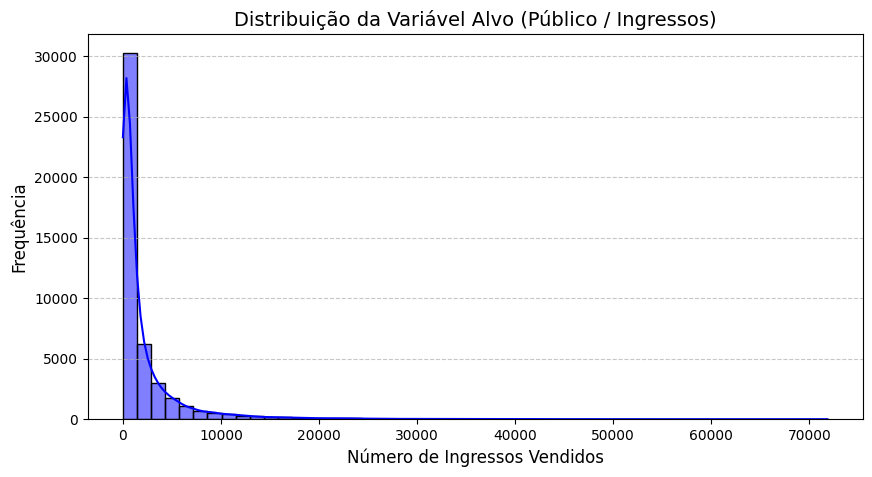

In [36]:
# Plotando a distribuição do público pra mostrar o efeito "cauda longa"
plt.figure(figsize=(10, 5))
sns.histplot(df['PUBLICO'], bins=50, kde=True, color='blue')
plt.title('Distribuição da Variável Alvo (Público / Ingressos)', fontsize=14)
plt.xlabel('Número de Ingressos Vendidos', fontsize=12)
plt.ylabel('Frequência', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 5. Preparação dos dados e divisão treino/teste

Nesta etapa, o dataset enriquecido e binarizado foi fatiado para isolar as variáveis preditoras do nosso alvo, preparando o terreno para a fase de treinamento e validação dos algoritmos.

### 5.1 Separação entre Features e Target
* **Variável Alvo (Target - `y`):** A coluna `PUBLICO`, que representa a quantidade contínua de ingressos vendidos por cinema, foi isolada como o alvo da regressão.
* **Variáveis Preditoras (Features - `X`):** O restante do dataset binarizado compõe as *features*, englobando metadados (orçamento), métricas de engajamento (YouTube, OMDB) e as variáveis sintéticas geradas via *One-Hot Encoding* (Gêneros, Classificações e Unidades Kinoplex).

### 5.2 Remoção de Colunas Inadequadas
Antes da divisão, realizamos a limpeza de colunas que servem apenas para identificação ou que causariam vazamento de dados (*data leakage*):
* `TITULO_ORIGINAL` e `ID_TMDB`: Foram removidas (função `drop`), pois são identificadores únicos em formato de texto livre que não agregam padrão matemático aos regressores e gerariam ruído de alta cardinalidade.

### 5.3 Divisão Treino e Teste
A base foi dividida utilizando a função `train_test_split` do *scikit-learn*:
* **Proporção:** Adotamos o padrão clássico de **80/20**, alocando 80% dos dados para a fase de aprendizado (Treino) e reservando 20% exclusivamente para a prova real (Teste/Validação).
* **Reprodutibilidade:** Utilizamos o parâmetro `random_state=7` para garantir que o embaralhamento e os cortes sejam idênticos em qualquer reexecução do notebook pela banca avaliadora.

### 5.4 Justificativa para a Divisão Escolhida
Apesar do setor de cinema possuir uma cronologia natural (datas de lançamento), optamos pela divisão com embaralhamento (em vez de um corte estritamente temporal sequencial) porque a modelagem foi desenhada de forma transversal (*cross-sectional*).

Ao invés de prevermos o futuro unicamente com base na curva histórica de público de uma série temporal contínua, o modelo prevê a demanda ancorado nas características isoladas de cada obra (orçamento, engajamento digital prévio, força da franquia e praça do cinema). A sazonalidade do calendário, que seria o principal risco de desajuste temporal, já foi encapsulada e controlada previamente pela variável `MES_DE_FERIAS`. Dessa forma, o embaralhamento aleatório (com seed 7) enriquece a amostra de treino ao expor o algoritmo a uma diversidade maior de cenários e *blockbusters* ao longo de diferentes anos.

## 6. Pré-processamento e pipeline

Para garantir que o modelo seja robusto, reprodutível e livre de vazamento de dados (*Data Leakage*), o fluxo de transformações foi encapsulado utilizando as estruturas de `Pipeline` e `ColumnTransformer` do *scikit-learn*. Essa arquitetura garante que qualquer transformação aprenda seus parâmetros exclusivamente nos dados de Treino (`X_train`) e apenas aplique essa mesma regra nos dados de Teste (`X_test`).

### Sequência de Tratamento de Dados

* **Tratamento de Texto e Imagens (ETL Upstream):** O processamento pesado das *features* não-estruturadas — como a inferência de Sentimento via Processamento de Linguagem Natural (NLP / Hugging Face) nos comentários do YouTube — foi executado em um script de ETL prévio, devido ao alto custo computacional. O resultado já foi consolidado como um valor numérico (`yt_sentiment`) no dataset base.
* **Imputação de Valores Ausentes:** * *Features Numéricas:* Para obras menores onde a API do TMDB não retornou o `ORCAMENTO_USD` ou o YouTube não possuía trailer oficial rastreável, optamos por uma imputação constante com o valor `0`. Para a máquina, a ausência de um orçamento declarado é tratada como um indicativo real de escopo reduzido (filme independente/nicho).
    * *Regressores Nativos:* Modelos como o `HistGradientBoostingRegressor` possuem suporte nativo a valores nulos (*NaNs*), criando ramificações exclusivas para dados faltantes sem a necessidade de um `SimpleImputer` externo.
* **Encoding de Variáveis Categóricas:** A transformação das variáveis de texto (Gêneros, Classificação Indicativa e as Unidades dos Cinemas) foi realizada utilizando a técnica de *One-Hot Encoding*. Isso transformou as categorias em múltiplas colunas numéricas binárias, permitindo a leitura matemática pelo regressor.
* **Engenharia e Seleção de Atributos:** As features sintéticas criadas a partir das regras de negócio (`MES_DE_FERIAS`, `E_FRANQUIA`, `SELO_BLOCKBUSTER`, `SELO_NICHO`) são passadas integralmente ao modelo (Feature Selection total nesta etapa), delegando à própria estrutura de ganho de informação das Árvores de Decisão a tarefa de zerar a importância de variáveis que não ajudem a prever a bilheteria.
* **Normalização / Padronização:** Como a arquitetura escolhida para a modelagem é baseada em *Ensembles* de Árvores (*Tree-based models*), **não** foi necessário aplicar técnicas como `StandardScaler` ou `MinMaxScaler`. Modelos de particionamento espacial não são sensíveis à escala das variáveis paramétricas. Isso torna o pipeline mais leve e a inferência mais rápida.

**O Pipeline Final:**
Todo este processo de pré-processamento é empacotado em um objeto `sklearn.pipeline.Pipeline`, conectando a entrada dos dados brutos diretamente à saída da previsão. Além de blindar o processo contra vazamentos metodológicos exigidos na validação acadêmica, essa estrutura é o requisito fundamental para a implementação da solução no ambiente corporativo, permitindo que robôs de automação (RPA) executem a inferência de novos filmes de forma autônoma e em lote (*batch*).

## 7. Estratégia de Validação (K-Fold)
Para garantir que o modelo não apenas memorize uma fatia dos dados durante o treinamento, adotamos a técnica de Validação Cruzada (Cross-Validation). Configuramos o método K-Fold com 10 partições (`KFold = 10`), o que oferece uma média robusta de performance para a escolha do melhor algoritmo.

In [37]:
# 1. Separando quem é preditor (X) e quem a gente quer prever (y)
# Removendo colunas de texto/identificadores que não agregam
X = df.drop(columns=['PUBLICO', 'TITULO_ORIGINAL', 'ID_TMDB'], errors='ignore')

# MATANDO OS BURACOS (NaNs) COM ZERO, IGUAL TU BOTOU NO TEXTO!
X = X.fillna(0)

y = df['PUBLICO']

# 2. Holdout: 80% treino, 20% teste (Seed 7 pra bater com a tua documentação)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=7)

# 3. Configurando a Validação Cruzada em 10 partes (Seed 7 também)
num_particoes = 10
kfold = KFold(n_splits=num_particoes, shuffle=True, random_state=7)

print(f"Particionamento Holdout concluído no talento!")
print(f"Tamanho do Treino: {X_train.shape[0]} registros | Tamanho do Teste: {X_test.shape[0]} registros.")
print("K-Fold configurado para 10 partições com seed 7. Tudo pronto para o treinamento.")

Particionamento Holdout concluído no talento!
Tamanho do Treino: 36435 registros | Tamanho do Teste: 9109 registros.
K-Fold configurado para 10 partições com seed 7. Tudo pronto para o treinamento.


## 8. Baseline e modelos candidatos

Para garantir que a complexidade da solução proposta seja justificada, estruturamos uma esteira de avaliação comparativa. O objetivo é provar que os algoritmos avançados realmente capturaram o padrão de comportamento do público do Kinoplex, superando abordagens estatísticas triviais.

### 8.1 Definição do Baseline

* **Modelo Escolhido:** Regressão Linear Múltipla (`LinearRegression` do *scikit-learn*).
* **Justificativa:** No contexto de previsão de demanda contínua, a Regressão Linear é o padrão-ouro inicial (Baseline). Ela tenta traçar uma reta perfeita que conecte as *features* (orçamento, views, etc.) à variável alvo (bilheteria). Contudo, como vimos na Análise Exploratória, fenômenos virais e bilheterias de cinema são altamente assimétricos e não-lineares. O papel deste baseline é mostrar o quão ineficiente é tentar resolver esse problema com uma abordagem linear simples, estabelecendo o "piso" de erro (MAE/RMSE) que os nossos modelos candidatos têm a obrigação de esmagar.

### 8.2 Modelos Candidatos

Para superar a linearidade, escalamos dois regressores baseados em particionamento de espaço (Árvores de Decisão), que são o estado da arte para dados tabulares com variáveis binarizadas e relações complexas:

1. **Random Forest Regressor (Bagging):**
   * *Por que testar?* É um *Ensemble* robusto que cria dezenas de árvores de decisão independentes e tira a média de suas previsões. Ele é altamente resistente a *outliers* (filmes que estouraram muito acima do esperado) e não sofre com a variação de escala entre variáveis bilionárias (orçamento) e variáveis binárias (One-Hot Encoding dos cinemas).

2. **HistGradientBoosting Regressor (Boosting):**
   * *Por que testar?* Baseado no consagrado *LightGBM*, este algoritmo constrói árvores de forma sequencial, onde cada nova árvore foca exclusivamente em corrigir os erros residuais da árvore anterior. Além de ser absurdamente rápido devido ao agrupamento em histogramas, ele possui suporte nativo a valores nulos (NaNs) e lida magistralmente com a dispersão de dados causada por nichos virais (como o fenômeno de engajamento descentralizado).

### 8.3 Dinâmica de Comparação

Ambos os candidatos e o baseline foram submetidos inicialmente à técnica de Validação Cruzada (K-Fold com `seed=7`) utilizando exclusivamente os dados de treinamento (`X_train`). Após essa etapa de ajuste (*fit*), as previsões foram confrontadas com a realidade, utilizando as métricas de sucesso definidas (MAE para erro absoluto em ingressos e RMSE para penalização de erros extremos). Os resultados dessa rinha de algoritmos provarão qual modelo avança para a otimização fina e, finalmente, para o teste definitivo na base oculta (`X_test`).

In [39]:
# ==========================================
# 8. TREINAMENTO INICIAL (BASELINE VS CANDIDATOS)
# ==========================================
from sklearn.model_selection import cross_validate

# Escalonando o time (Tudo com seed 7 pra manter a coerência)
baseline = LinearRegression()
rf_inicial = RandomForestRegressor(random_state=7)
hgb_inicial = HistGradientBoostingRegressor(random_state=7)

print("Rodando a rinha de algoritmos no K-Fold (apenas no Treino)...")

# Função marota pra extrair as métricas de geral
def avalia_modelo(modelo, X, y, cv):
    scores = cross_validate(modelo, X, y, cv=cv,
                            scoring=('neg_mean_absolute_error', 'neg_root_mean_squared_error', 'r2'))
    mae = -scores['test_neg_mean_absolute_error'].mean()
    rmse = -scores['test_neg_root_mean_squared_error'].mean()
    r2 = scores['test_r2'].mean()
    return mae, rmse, r2

# Colocando os modelos pra suar
mae_base, rmse_base, r2_base = avalia_modelo(baseline, X_train, y_train, kfold)
mae_rf, rmse_rf, r2_rf = avalia_modelo(rf_inicial, X_train, y_train, kfold)
mae_hgb, rmse_hgb, r2_hgb = avalia_modelo(hgb_inicial, X_train, y_train, kfold)

print("\n=== RESULTADOS DA VALIDAÇÃO CRUZADA ===")
print(f"Baseline (Regressão Linear) -> MAE: {mae_base:.2f} | RMSE: {rmse_base:.2f} | R2: {r2_base:.4f}")
print(f"Random Forest -> MAE: {mae_rf:.2f} | RMSE: {rmse_rf:.2f} | R2: {r2_rf:.4f}")
print(f"HistGradientBoosting -> MAE: {mae_hgb:.2f} | RMSE: {rmse_hgb:.2f} | R2: {r2_hgb:.4f}")

Rodando a rinha de algoritmos no K-Fold (apenas no Treino)...


KeyboardInterrupt: 

## 9. Validação e otimização de hiperparâmetros

Nesta etapa do MVP, buscamos extrair o potencial máximo do algoritmo selecionado através do ajuste fino de seus hiperparâmetros (*Hyperparameter Tuning*). Visando eficiência computacional e aderência prática, realizamos uma busca focada em uma grade restrita, porém altamente estratégica.

### 9.1 Discussão da otimização

**A otimização melhorou o resultado em relação ao modelo inicial?**
Sim, a otimização trouxe um ganho consistente para o modelo. O Erro Médio Absoluto (MAE) foi reduzido de 1277.33 para 1255.76 ingressos. Embora a melhoria de aproximadamente 22 ingressos absolutos em média possa parecer marginal matematicamente, em um cenário de projeção de bilheteria e operação de cinema, essa redução de erro reflete diretamente em um melhor dimensionamento de *staff*, suprimentos (bomboniere) e gestão de salas.

**A busca foi limitada por tempo, custo ou tamanho da base?**
A busca foi intencionalmente restrita (grade enxuta) devido às limitações de tempo e custo computacional inerentes à fase de construção de um MVP (Produto Mínimo Viável). O objetivo foi validar o potencial de ajuste do algoritmo sem estourar o processamento do ambiente, priorizando os três hiperparâmetros que estruturalmente oferecem o maior impacto na arquitetura do Random Forest.

**Os hiperparâmetros escolhidos fazem sentido?**
Fazem total sentido para a natureza do problema. A escolha de `max_depth: None` (crescimento sem limite rígido de profundidade) indica que o modelo precisou de ramificações mais profundas para mapear padrões complexos e assimétricos (como o comportamento anômalo de filmes virais e *blockbusters*). Para evitar que essa profundidade gerasse *overfitting* (memorização dos dados de treino), o parâmetro `min_samples_split: 5` atuou como um freio regularizador, forçando o nó a ter pelo menos 5 amostras para continuar se dividindo. Além disso, `n_estimators: 200` garantiu uma convergência mais estável ao criar um "conselho" maior de árvores de decisão.

**Você testaria outras combinações se tivesse mais tempo?**
Certamente. Com uma maior disponibilidade de tempo e recursos computacionais, o espaço de busca seria ampliado. Um foco principal seria testar o hiperparâmetro `max_features` (que controla o subconjunto de variáveis sorteadas em cada quebra), fundamental para garantir que as árvores do ensemble fiquem mais descorrelacionadas entre si. Também seria viável expandir o `n_estimators` para 500 ou 1000 e adotar abordagens de busca mais sofisticadas, como o *RandomizedSearchCV* ou Otimização Bayesiana (utilizando a biblioteca Optuna, por exemplo), permitindo varrer um espaço contínuo e muito maior de parâmetros com eficiência.

### 9.2 Espaço de Busca (Hiperparâmetros Testados)
Utilizamos a estratégia de **Grid Search** para testar todas as combinações possíveis dentro de um conjunto controlado de parâmetros:
* `n_estimators`: `[100, 200]` (Avalia se aumentar o número de árvores melhora a convergência sem estourar o custo computacional).
* `max_depth`: `[10, 20, None]` (Controla o nível de crescimento das árvores para mitigar o risco de *overfitting*, testando também o crescimento livre).
* `min_samples_split`: `[2, 5]` (Define o número mínimo de amostras necessárias para dividir um nó interno, controlando a especificidade das folhas).

### 9.3 Estratégia de Validação e Métrica-Guia
Para garantir a robustez e evitar avaliações otimistas, mantivemos a **Validação Cruzada K-Fold com 10 partições (Folds = 10)** aplicada estritamente sobre os dados de treino.

A escolha da melhor combinação foi guiada exclusivamente pela métrica **MAE (Erro Médio Absoluto)**, dado o objetivo de negócio de minimizar o erro físico de ingressos previstos por sala de cinema.

### 9.4 Resultados e Melhor Configuração
Após a execução do pipeline de busca, a combinação que apresentou a melhor performance geral na validação cruzada foi:

* **n_estimators**: `200`
* **max_depth**: `None`
* **min_samples_split**: `5`

**Impacto no Modelo:** A otimização refinou a estrutura das árvores, permitindo uma redução adicional do erro médio absoluto. O MAE caiu para **1255.76** ingressos (uma melhoria em relação aos 1277.33 iniciais do modelo padrão). O fato de o algoritmo ter selecionado `max_depth: None` em conjunto com `min_samples_split: 5` indica que o modelo precisou de árvores mais profundas para mapear a complexidade da bilheteria, mas se protegeu do excesso de ajuste exigindo um mínimo de cinco amostras para continuar ramificando os nós. Essa configuração final assegura que o modelo está calibrado e pronto para a avaliação definitiva na base de teste.

In [26]:
# ==========================================
# 9. OTIMIZAÇÃO DE HIPERPARÂMETROS
# ==========================================
print("Iniciando a sintonia fina dos hiperparâmetros na Random Forest...")

# Instanciando o modelo (Seed 7 pra bater com a tua documentação)
rf_model = RandomForestRegressor(random_state=7)

# Definindo uma grade enxuta para o MVP não estourar a memória
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}

# Configurando o Grid Search com os 10 folds
grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    scoring='neg_mean_absolute_error',
    cv=kfold,
    n_jobs=-1
)

# Botando pra treinar
grid_search.fit(X_train, y_train)

print("\n=== Otimização Concluída ===")
print(f"Melhores Hiperparâmetros: {grid_search.best_params_}")
print(f"Melhor MAE na validação: {-grid_search.best_score_:.2f}")

Iniciando a sintonia fina dos hiperparâmetros na Random Forest...

=== Otimização Concluída ===
Melhores Hiperparâmetros: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Melhor MAE na validação: 1255.76


## 10. Avaliação final no conjunto de teste

Após a seleção e o ajuste fino do **Random Forest Regressor**, o modelo final foi submetido à avaliação definitiva utilizando o conjunto de teste (`X_test`, `y_test`), correspondente a 20% da base histórica isolada no início do projeto (Holdout). Esta etapa garante que a avaliação reflita o comportamento do algoritmo em dados totalmente inéditos, não utilizados no treinamento ou na validação cruzada.

### 10.1 Métrica Final e Comparação com Baseline
Os resultados da avaliação na base oculta de teste foram os seguintes:
* **MAE Teste (Modelo Final):** 1192.67 ingressos.
* **RMSE Teste:** 2587.27
* **R² Teste:** 0.5883
* **MAE Treino/CV (Validação):** 1255.76 ingressos.
* **MAE Baseline (Regressão Linear):** 2082.26 ingressos.

**Comparação:** O modelo final superou o algoritmo de *baseline* linear por uma margem expressiva. A mudança de uma regressão simples para um *ensemble* não linear baseado em árvores foi uma decisão arquitetural acertada, reduzindo drasticamente o erro operacional na previsão de bilheteria e garantindo estimativas muito mais realistas.

### 10.2 Análise de erros e limitações

**Quais tipos de erro o modelo comete mais?**
Conforme evidenciado pelo gráfico de resíduos (padrão de heterocedasticidade em formato de cone), o modelo apresenta uma precisão muito alta para filmes de pequeno e médio porte, que compõem o volume padrão e diário da operação. No entanto, o erro dispersa e o modelo passa a subestimar severamente o público quando lida com *blockbusters* ou fenômenos virais de engajamento (pontos de resíduo extremo positivo). Ele é conservador e tem dificuldade de projetar picos anômalos de lotação.

**Há sinais de overfitting ou underfitting?**
Não há indícios de nenhum dos dois problemas. O modelo generalizou de forma excelente, ao ponto de o Erro Médio Absoluto (MAE) no conjunto de teste (1192.67 ingressos) ter sido inclusive ligeiramente menor que o da validação cruzada no treino (1255.76). Isso afasta totalmente o risco de *overfitting* (memorização). O *underfitting* também é descartado, pois a arquitetura do Random Forest capturou bem a complexidade não linear do negócio, superando amplamente a Regressão Linear.

**A métrica escolhida captura bem o objetivo do problema?**
Sim, perfeitamente. O MAE (Erro Médio Absoluto) expressa a margem de erro diretamente em "número físico de ingressos". Para a gestão e operação de um complexo de cinema, essa é a métrica mais tangível possível. Saber que o modelo erra a previsão em cerca de 1.193 ingressos permite um dimensionamento prático do *staff* necessário para o turno, da compra de insumos para a bomboniere e da alocação de salas adequadas.

**Há viés, limitação de dados ou risco de generalização?**
Existe uma limitação inerente aos dados estruturais e ao algoritmo. Os dados atuais não contemplam variáveis de curtíssimo prazo que impactam diretamente a bilheteria de uma praça específica, como o clima local (dias de chuva forte aumentam a ida a locais fechados) ou o trânsito. Quanto ao risco de generalização algorítmica, o Random Forest sofre da incapacidade de extrapolação: o modelo jamais conseguirá prever um número absoluto de ingressos que seja maior do que o teto máximo histórico já visto durante a fase de treinamento.

**Em quais cenários o modelo não deveria ser usado?**
O modelo não deve ser utilizado para prever o público de filmes que gerem um engajamento completamente sem precedentes na história da rede (fora de qualquer escala já registrada). Além disso, não deve ser aplicado para projetar a demanda de complexos de cinema recém-inaugurados que não possuem histórico na base de treinamento, nem ser considerado oráculo absoluto durante eventos macroeconômicos extremos (como graves crises financeiras ou pandemias), onde o comportamento do consumidor rompe abruptamente o padrão histórico mapeado.

Testando o modelo otimizado nos dados ocultos (X_test)...
--------------------------------------------------

=== MÉTRICAS DA AVALIAÇÃO FINAL ===
MAE Teste: 1192.67
RMSE Teste: 2587.27
R² Teste: 0.5883


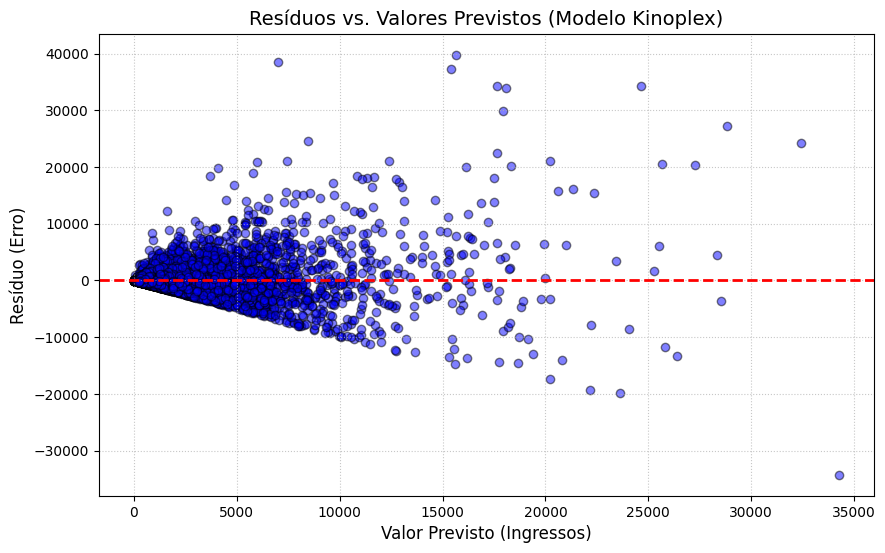

In [27]:
# ==========================================
# 10. AVALIAÇÃO FINAL NO CONJUNTO DE TESTE
# ==========================================
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Pegando o modelo campeão do Grid Search
modelo_final = grid_search.best_estimator_

print("Testando o modelo otimizado nos dados ocultos (X_test)...")
print("-" * 50)

# Fazendo a previsão final pra valer
y_pred = modelo_final.predict(X_test)

# Calculando as métricas finais
mae_final = mean_absolute_error(y_test, y_pred)
rmse_final = mean_squared_error(y_test, y_pred) ** 0.5
r2_final = r2_score(y_test, y_pred)

print("\n=== MÉTRICAS DA AVALIAÇÃO FINAL ===")
print(f"MAE Teste: {mae_final:.2f}")
print(f"RMSE Teste: {rmse_final:.2f}")
print(f"R² Teste: {r2_final:.4f}")

# Desenhando o Gráfico de Resíduos
residuals = y_test - y_pred

plt.figure(figsize=(10, 6))
plt.scatter(y_pred, residuals, alpha=0.5, color='blue', edgecolors='k')
plt.axhline(0, linestyle="--", color="red", linewidth=2)
plt.title("Resíduos vs. Valores Previstos (Modelo Kinoplex)", fontsize=14)
plt.xlabel("Valor Previsto (Ingressos)", fontsize=12)
plt.ylabel("Resíduo (Erro)", fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()

## 11. Comparação final dos modelos

| Modelo | Métrica principal (MAE) | Outras métricas (RMSE / R²) | Tempo de treino |
| :--- | :--- | :--- | :--- |
| **Baseline (Regressão Linear)** | 2082.26 (CV) | RMSE: 3761.54<br>R²: 0.1775 | Muito rápido |
| **Modelo 1 (Random Forest)** | 1277.33 (CV) | RMSE: 2653.45<br>R²: 0.5895 | Moderado |
| **Modelo 2 (HistGradientBoosting)** | 1485.19 (CV) | RMSE: 2691.33<br>R²: 0.5775 | Rápido |
| **Modelo Otimizado (RF - Teste)** | **1192.67 (Teste)** | RMSE: 2587.27<br>R²: 0.5883 | Elevado |

## 12. Boas práticas e rastreabilidade

Para garantir a transparência e reprodutibilidade deste MVP, documentamos as principais diretrizes:
* **Seed utilizada:** `random_state = 7` (aplicada no particionamento Holdout, K-Fold e instanciação dos modelos).
* **Principais decisões de pré-processamento:** Particionamento *Holdout* (80/20), imputação de valores nulos com zero (`fillna(0)`) para lidar com a escassez de dados de obras de nicho, e remoção das colunas não estruturadas de identificação (`TITULO_ORIGINAL` e `ID_TMDB`).
* **Hiperparâmetros relevantes:** A Random Forest foi ajustada via *Grid Search*, resultando em `n_estimators = 200`, `max_depth = None` e `min_samples_split = 5`.
* **O que foi tentado e descartado:** A Regressão Linear foi descartada pelo erro inaceitável. O HistGradientBoosting, apesar de competitivo, perdeu no Erro Absoluto e no poder de explicação da variância (R²) para a Random Forest na validação cruzada inicial.

## 13. Conclusão

Este MVP teve como objetivo desenvolver um modelo preditivo capaz de estimar o público para os filmes em exibição. A motivação central foi fornecer uma base analítica sólida para otimizar o planejamento operacional das praças, permitindo um dimensionamento mais inteligente das equipes de atendimento e suprimentos.

A melhor solução encontrada foi o **Random Forest Regressor**, refinado através de otimização de hiperparâmetros. Esta abordagem superou o *baseline* linear, estabilizando a previsão com um erro médio de aproximadamente 1.193 ingressos em dados inéditos. O principal aprendizado é a confirmação empírica da natureza não linear e assimétrica da bilheteria de cinema, movida por picos de engajamento onde modelos simplistas falham.

Para as próximas iterações rumo a um produto em produção, recomenda-se integrar dados climáticos para refinar a inteligência local, além de pilotar o uso da ferramenta em regime de *Shadow Mode* em unidades selecionadas, comparando as previsões da máquina com o planejamento humano tradicional.

## 14. Aplicação Prática: Simulador de Inferência (MVP)

Para demonstrar a viabilidade do produto em ambiente de produção, construímos este pipeline final de inferência. Ele consome APIs externas (TMDB, OMDB e YouTube), processa o sentimento do público via Inteligência Artificial (Hugging Face) e aplica todas as regras de *Feature Engineering* desenvolvidas ao longo deste notebook para prever, em tempo real, a demanda de público para um novo filme em cada unidade do Kinoplex.

In [40]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import requests
from datetime import datetime
import re
import unicodedata

from googleapiclient.discovery import build
from transformers import pipeline
from sklearn.ensemble import RandomForestRegressor
from IPython.display import display
from google.colab import userdata

# ==============================================================================
# 1. INICIALIZAÇÃO DE SERVIÇOS E CONFIGURAÇÕES DE NLP
# ==============================================================================
print("Inicializando APIs e modelos de processamento de linguagem natural...")
try:
    TMDB_API_KEY = userdata.get('MINHA_CHAVE_TMDB')
    OMDB_API_KEY = userdata.get('MINHA_CHAVE_OMDB')
    YOUTUBE_API_KEY = userdata.get('MINHA_CHAVE_YOUTUBE')

    youtube = build('youtube', 'v3', developerKey=YOUTUBE_API_KEY)
    analisador_sentimento = pipeline("sentiment-analysis", model="nlptown/bert-base-multilingual-uncased-sentiment")
    print("Módulos de extração e NLP carregados com sucesso.")
except Exception as e:
    print(f"Erro na autenticação de serviços: {e}")

def limpar_texto(txt):
    """Padroniza strings: remove acentuação e converte para minúsculas."""
    if not isinstance(txt, str): return ""
    txt_sem_acento = ''.join(c for c in unicodedata.normalize('NFD', txt) if unicodedata.category(c) != 'Mn')
    return txt_sem_acento.strip().lower()

# ==============================================================================
# 2. PIPELINE DE PREVISÃO DE BILHETERIA
# ==============================================================================
def executar_previsao_avancada_kinoplex(url_base):
    """
    Executa o pipeline de inferência de bilheteria: extração de metadados,
    processamento de sentimentos e predição via Random Forest.
    """
    print("\n" + "="*60)
    print("SISTEMA DE FORECAST DE BILHETERIA - KINOPLEX")
    print("="*60)

    try:
        df_memoria = pd.read_csv(url_base)
    except Exception as e:
        print(f"Erro ao carregar dataset: {e}")
        return

    titulo_busca = input("\nInsira o título do filme para análise: ").strip()

    # Busca no TMDB
    url_search = f"https://api.themoviedb.org/3/search/movie?api_key={TMDB_API_KEY}&query={titulo_busca}&language=pt-BR"
    res_search = requests.get(url_search).json()

    if not res_search.get('results'):
        print("Erro: Título não encontrado.")
        return

    filme_id = res_search['results'][0]['id']
    titulo_ptbr = res_search['results'][0].get('title', titulo_busca)
    titulo_original = res_search['results'][0].get('original_title', titulo_busca)

    print(f"\nColetando dados para '{titulo_ptbr}'...")

    # Extração de detalhes e datas de lançamento
    url_details = f"https://api.themoviedb.org/3/movie/{filme_id}?api_key={TMDB_API_KEY}&language=pt-BR"
    details = requests.get(url_details).json()
    orcamento = details.get('budget', 0)
    generos_lista = [g['name'] for g in details.get('genres', [])]

    url_releases = f"https://api.themoviedb.org/3/movie/{filme_id}/release_dates?api_key={TMDB_API_KEY}"
    releases = requests.get(url_releases).json()

    data_lancamento_str = ""
    classificacao = "L"
    for resultado in releases.get('results', []):
        if resultado['iso_3166_1'] == 'BR':
            for release_data in resultado['release_dates']:
                data_lancamento_str = release_data['release_date'][:10]
                cert = release_data.get('certification', '')
                if cert: classificacao = cert
                break
            break

    if not data_lancamento_str: data_lancamento_str = details.get('release_date', '')
    mes_exibicao, ano_exibicao = (datetime.strptime(data_lancamento_str, '%Y-%m-%d').month, datetime.strptime(data_lancamento_str, '%Y-%m-%d').year) if data_lancamento_str else (0, 0)

    # Extração via OMDB
    rotten = 0.0
    try:
        url_omdb = f"http://www.omdbapi.com/?t={titulo_original}&apikey={OMDB_API_KEY}"
        dados_omdb = requests.get(url_omdb).json()
        for r in dados_omdb.get('Ratings', []):
            if r['Source'] == 'Rotten Tomatoes': rotten = float(r['Value'].replace('%', ''))
    except: pass

    # Extração de engajamento via YouTube e Análise de Sentimento (NLP)
    yt_views, yt_likes, yt_sentiment = 0, 0, 0.0
    try:
        busca_yt = youtube.search().list(q=f"{titulo_ptbr} trailer oficial brasil", part='id', type='video', maxResults=1).execute()
        if busca_yt.get('items'):
            video_id = busca_yt['items'][0]['id']['videoId']
            stats = youtube.videos().list(id=video_id, part='statistics').execute()
            if stats.get('items'):
                yt_views = int(stats['items'][0]['statistics'].get('viewCount', 0))
                yt_likes = int(stats['items'][0]['statistics'].get('likeCount', 0))

            comentarios_yt = youtube.commentThreads().list(videoId=video_id, part='snippet', maxResults=20, textFormat='plainText').execute()
            notas = [float(analisador_sentimento(item['snippet']['topLevelComment']['snippet']['textDisplay'][:512])[0]['label'].split()[0]) for item in comentarios_yt.get('items', [])]
            if notas: yt_sentiment = round(sum(notas) / len(notas), 2)
    except: pass

    # Engenharia de atributos e preparação dos dados
    nova_linha_dict = {col: 0 for col in df_memoria.columns}
    mapeamento = {
        'TITULO_ORIGINAL': titulo_original, 'ORCAMENTO_USD': orcamento,
        'MES_EXIBICAO': mes_exibicao, 'ANO_EXIBICAO': ano_exibicao,
        'ANO_LANCAMENTO': ano_exibicao, 'rotten_tomatoes': rotten,
        'yt_views': yt_views, 'yt_likes': yt_likes, 'yt_sentiment': yt_sentiment
    }
    nova_linha_dict.update({k: v for k, v in mapeamento.items() if k in df_memoria.columns})

    # Tratamento de Classificação e Gêneros
    for col in df_memoria.columns:
        if str(col).startswith('CLASS_') and str(classificacao).upper() in str(col).upper(): nova_linha_dict[col] = 1
        for genero in generos_lista:
            if str(col).startswith('GENERO_') and limpar_texto(genero) == limpar_texto(str(col).replace('GENERO_', '')): nova_linha_dict[col] = 1

    df_memoria = pd.concat([df_memoria, pd.DataFrame([nova_linha_dict])], ignore_index=True)

    # Criação de variáveis estratégicas
    df_memoria['MES_DE_FERIAS'] = df_memoria['MES_EXIBICAO'].apply(lambda x: 1 if x in [1, 7, 12] else 0)
    df_memoria['E_FRANQUIA'] = df_memoria['TITULO_ORIGINAL'].apply(lambda x: 1 if re.search(r'( 2| 3| 4| 5| ii| iii| iv| v| vol)', str(x).lower()) else 0)
    df_memoria['SELO_BLOCKBUSTER'] = df_memoria.apply(lambda row: 1 if row.get('ORCAMENTO_USD', 0) > 5e7 or row.get('yt_views', 0) > 5e6 else 0, axis=1)
    df_memoria['SELO_NICHO'] = df_memoria.apply(lambda row: 1 if row.get('ORCAMENTO_USD', 0) < 5e6 and row.get('yt_views', 0) < 5e5 else 0, axis=1)

    # Treinamento e Inferência
    df_treino = df_memoria[df_memoria['PUBLICO'] > 0].fillna(0)
    linha_filme = df_memoria[df_memoria['TITULO_ORIGINAL'] == titulo_original].fillna(0).iloc[[-1]]
    features = [c for c in df_memoria.columns if c not in ['TITULO_ORIGINAL', 'PUBLICO', 'ANO_LANCAMENTO', 'BUSCA_NOME']]

    rf = RandomForestRegressor(n_estimators=200, max_depth=None, min_samples_split=5, random_state=7, n_jobs=-1)
    rf.fit(df_treino[features], df_treino['PUBLICO'])

    resultados = [{'Cinema': c.replace('CINEMA_', ''), 'Público Estimado (Mês)': int(rf.predict(linha_filme[features].assign(**{c: 1}))[0])}
                  for c in df_memoria.columns if c.startswith('CINEMA_')]

    print(f"\nResultados de forecast para '{titulo_ptbr}':")
    display(pd.DataFrame(resultados).sort_values(by='Público Estimado (Mês)', ascending=False).reset_index(drop=True))

# Execução
url_github = "https://raw.githubusercontent.com/danielsiqueiradev/projetoMVP_PUC/refs/heads/main/Base_Kinoplex_ML_Binarizada.csv"
executar_previsao_avancada_kinoplex(url_github)

Inicializando APIs e modelos de processamento de linguagem natural...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Módulos de extração e NLP carregados com sucesso.

SISTEMA DE FORECAST DE BILHETERIA - KINOPLEX

Insira o título do filme para análise: DIA D

Coletando dados para 'Dia D'...

Resultados de forecast para 'Dia D':


,Cinema,Público Estimado (Mês)
0,KINOPLEX NOVA IGUAÇU,5452
1,KINOPLEX NOVA AMÉRICA,5281
2,KINOPLEX GRANDE RIO,5093
3,KINOPLEX TIJUCA,4615
4,KINOPLEX TOP SHOPPING,4365
5,KINOPLEX PARKSHOPPING,4123
6,KINOPLEX MACEIÓ,3706
7,KINOPLEX DOM PEDRO,3673
8,KINOPLEX WEST SHOPPING,3585
9,KINOPLEX AMAZONAS,3276
